# 📌 DoctorGPT v1: Initialization & Setup

#📦 Install Required Packages

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:


!pip install -U transformers datasets accelerate bitsandbytes peft


#🧠 Step 2: Load Model and Tokenizer
python
Copy
Edit


# 🧠 Dataset Formatting & Tokenization

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM

model_name = "microsoft/phi-2"

tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto",
    load_in_4bit=True,
    trust_remote_code=True
)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/7.34k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.11M [00:00<?, ?B/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/564M [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

#📚 Step 3: Load MedQuAD Dataset
python
Copy
Edit


In [ ]:
from datasets import load_dataset

dataset = load_dataset("keivalya/MedQuad-MedicalQnADataset")
print(dataset['train'][0])


README.md:   0%|          | 0.00/233 [00:00<?, ?B/s]

medDataset_processed.csv:   0%|          | 0.00/22.5M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16407 [00:00<?, ? examples/s]

{'qtype': 'susceptibility', 'Question': 'Who is at risk for Lymphocytic Choriomeningitis (LCM)? ?', 'Answer': 'LCMV infections can occur after exposure to fresh urine, droppings, saliva, or nesting materials from infected rodents.  Transmission may also occur when these materials are directly introduced into broken skin, the nose, the eyes, or the mouth, or presumably, via the bite of an infected rodent. Person-to-person transmission has not been reported, with the exception of vertical transmission from infected mother to fetus, and rarely, through organ transplantation.'}


In [ ]:
def format_prompt(example):
    question = example['Question']
    answer = example['Answer']
    return {
        "text": f"Question: {question}\n\nAnswer: {answer}"
    }

formatted_dataset = dataset['train'].map(format_prompt)
print(formatted_dataset[0]['text'])


Map:   0%|          | 0/16407 [00:00<?, ? examples/s]

Question: Who is at risk for Lymphocytic Choriomeningitis (LCM)? ?

Answer: LCMV infections can occur after exposure to fresh urine, droppings, saliva, or nesting materials from infected rodents.  Transmission may also occur when these materials are directly introduced into broken skin, the nose, the eyes, or the mouth, or presumably, via the bite of an infected rodent. Person-to-person transmission has not been reported, with the exception of vertical transmission from infected mother to fetus, and rarely, through organ transplantation.


In [ ]:
from datasets import Dataset
# Fix padding issue
tokenizer.pad_token = tokenizer.eos_token

# Only keep 'text' column
train_data = formatted_dataset.remove_columns(
    [col for col in formatted_dataset.column_names if col != 'text']
)

def tokenize_function(example):
    return tokenizer(
        example["text"],
        truncation=True,
        padding="max_length",
        max_length=512
    )

tokenized_train = train_data.map(tokenize_function, batched=True)




Map:   0%|          | 0/16407 [00:00<?, ? examples/s]

# 🏋️ Model Training & Checkpoint Management

In [ ]:
# Confirm keys
print(tokenized_train[0].keys())


dict_keys(['text', 'input_ids', 'attention_mask'])


#🚀 Step: Prepare Model for QLoRA Fine-tuning

In [ ]:
from peft import prepare_model_for_kbit_training, LoraConfig, get_peft_model

# Prepare Phi-2 model for 4-bit training
model = prepare_model_for_kbit_training(model)

# LoRA config
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"],  # Key for causal LM like Phi-2
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

# Add LoRA adapter to the model
model = get_peft_model(model, lora_config)


#⚙️ Step: Set Training Arguments

# 📥 Checkpoint Evaluation (Manual Loop / BERTScore)

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="/content/doctor_gpt_v1",
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    num_train_epochs=2,
    save_steps=500,
    logging_steps=100,
    learning_rate=2e-4,
    bf16=False,
    fp16=True,
    report_to="none"
)


In [ ]:
import transformers
print(transformers.__version__)

4.51.3


# Step: Data Collator for Causal LM

In [ ]:
from transformers import DataCollatorForLanguageModeling

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False  # We're doing causal LM, not masked LM
)


#🧠 Step: Define Trainer

In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    tokenizer=tokenizer,
    data_collator=data_collator
)


<ipython-input-12-94733b94aaef>:3: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


#🚀 Step: Train the Model



In [ ]:
# Input: where your model was last saved
model_checkpoint = "/content/drive/MyDrive/doctor_gpt_v1"

# Output: where to save continued training checkpoints
output_dir = "/content/drive/MyDrive/doctor_gpt_v1_continued"


# 🔍 Sample Inference & Visual QA Comparison

In [ ]:
trainer.train()


#💾 After Training: Save Model

In [ ]:
output_path = "/content/drive/MyDrive/doctor_gpt_v1"

trainer.save_model(output_path)
tokenizer.save_pretrained(output_path)


# Loading the model from drive and Evaluating

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline

model_path = "/content/drive/MyDrive/doctor_gpt_v1"  # adjust if needed

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForCausalLM.from_pretrained(model_path)

qa_pipeline = pipeline("text-generation", model=model, tokenizer=tokenizer)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Device set to use cuda:0


## Checking the prediction for the first time

In [ ]:
prompt = "What are the symptoms of ulcer?"
output = qa_pipeline(prompt, max_new_tokens=200)[0]["generated_text"]
print(output)


What are the symptoms of ulcer?

Ulcers can cause a variety of symptoms, depending on their location and severity. Some common symptoms include:

- Pain: The most common symptom of an ulcer is pain, which can range from mild to severe. The pain may be sharp, burning, or gnawing, and may occur in the stomach, duodenum, or esophagus. The pain may be triggered by eating, drinking, or lying down, and may last for several hours or days.
- Nausea and vomiting: Nausea and vomiting are common symptoms of stomach ulcers, especially when the ulcer is bleeding or infected. Nausea and vomiting may occur before or after eating, and may be accompanied by blood in the vomit or stool.
- Heartburn: Heartburn is a burning sensation in the chest or throat that occurs when stomach acid flows back into the esophagus. Heartburn may be a symptom of duodenal ulcers, which are ul


##Comparing predicted and expected answers

In [ ]:
test_data = [
    {"question": "What are the symptoms of diabetes?", "answer": "Increased thirst, frequent urination, and fatigue."},
    {"question": "Can asthma be cured?", "answer": "There is no cure, but it can be managed with medication."},
    {"question": "What is the normal blood sugar level?", "answer": "Between 70 and 99 mg/dL when fasting."},
]

In [ ]:
for item in test_data:
    prompt = item["question"]
    reference = item["answer"]

    output = qa_pipeline(prompt, max_new_tokens=150)[0]["generated_text"]

    print(f"Question: {prompt}")
    print(f"Generated Answer: {output}")
    print(f"Expected Answer: {reference}")
    print("-" * 80)


Question: What are the symptoms of diabetes?
Generated Answer: What are the symptoms of diabetes?

The symptoms of diabetes can vary from person to person. Some people may have no symptoms at all, while others may have symptoms that are mild or severe. The most common symptoms of diabetes are:

- Increased thirst and urination
- Hunger and weight loss
- Fatigue and weakness
- Blurred vision
- Slow healing of wounds
- Numbness or tingling in the hands or feet
- Recurring infections
- Erectile dysfunction in men

The symptoms of diabetes can develop gradually over time, or they can appear suddenly. If you have any of these symptoms, you should see your doctor as soon as possible. Early diagnosis and treatment can help prevent or delay the complications of diabetes.

Expected Answer: Increased thirst, frequent urination, and fatigue.
--------------------------------------------------------------------------------
Question: Can asthma be cured?
Generated Answer: Can asthma be cured?

Answe

##Testing One sample with bert

In [ ]:
!pip install bert-score

In [ ]:
import nltk
import json
from bert_score import score
from nltk.tokenize import sent_tokenize

nltk.download('punkt')
import re


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [ ]:
from bert_score import score

# Replace these with your real outputs
expected_answer = "Increased thirst, frequent urination, and fatigue."
predicted_answer = """
What are the symptoms of diabetes?

The symptoms of diabetes can vary from person to person. Some people may have no symptoms at all, while others may have symptoms that are mild or severe. The most common symptoms of diabetes are:

- Increased thirst and urination
- Hunger and weight loss
- Fatigue and weakness
- Blurred vision
- Slow healing of wounds
- Numbness or tingling in the hands or feet
- Recurring infections
- Erectile dysfunction in men

The symptoms of diabetes can develop gradually over time, or they can appear suddenly. If you have any of these symptoms, you should see your doctor as soon as possible. Early diagnosis and treatment can help prevent or delay the complications of diabetes.
"""

# Evaluate with BERTScore
P, R, F1 = score([predicted_answer], [expected_answer], lang="en", verbose=True)

print(f"\n🔍 BERTScore Evaluation:")
print(f"Precision:  {P[0].item():.4f}")
print(f"Recall:     {R[0].item():.4f}")
print(f"F1 Score:   {F1[0].item():.4f}")


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

calculating scores...
computing bert embedding.


  0%|          | 0/1 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/1 [00:00<?, ?it/s]

done in 0.96 seconds, 1.04 sentences/sec

🔍 BERTScore Evaluation:
Precision:  0.7959
Recall:     0.9009
F1 Score:   0.8451


## Testing from the samples taken from medquad dataset

In [ ]:

# Load JSON test file
with open("/content/medquad.json", "r") as f:
    data = json.load(f)

samples = data["documents"][:50]


for i, item in enumerate(samples[:20]):
    question = item["question"]
    expected = item["answer"].strip()

    prompt = f"Question: {question}\n\nAnswer:"
    output = qa_pipeline(prompt, max_new_tokens=160)[0]["generated_text"]
    raw_pred = output.split("Answer:")[-1].strip()

    # ⬇️ Sentence-Level Reranking by BERTScore (top 1 for high precision)
    sentences = re.split(r'(?<=[.?!])\s+', raw_pred.strip())

    if sentences:
        P, R, F1 = score(sentences, [expected]*len(sentences), lang="en", verbose=False)
        ranked = sorted(zip(sentences, F1), key=lambda x: x[1], reverse=True)
        refined_pred = ranked[0][0]  # Highest BERTScore sentence
    else:
        refined_pred = raw_pred  # fallback in case sentence split fails

    predictions.append(refined_pred)
    references.append(expected)



Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You sho

In [ ]:
P, R, F1 = score(predictions, references, lang="en", verbose=True)
print(f"\n🔍 Post-Rerank BERTScore:\nPrecision: {P.mean():.4f}\nRecall: {R.mean():.4f}\nF1 Score: {F1.mean():.4f}")

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


calculating scores...
computing bert embedding.


  0%|          | 0/1 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/1 [00:00<?, ?it/s]

done in 2.60 seconds, 7.69 sentences/sec

🔍 Post-Rerank BERTScore:
Precision: 0.8613
Recall: 0.8962
F1 Score: 0.8764


In [ ]:
#saving predictions and references
predictions_save= predictions
references_save= references

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Convert to list of floats
precision_scores = [p.item() for p in P]
recall_scores = [r.item() for r in R]
f1_scores = [f.item() for f in F1]

# Create DataFrame
import pandas as pd

df = pd.DataFrame({
    "Sample": list(range(1, len(predictions)+1)),
    "Precision": precision_scores,
    "Recall": recall_scores,
    "F1 Score": f1_scores
})


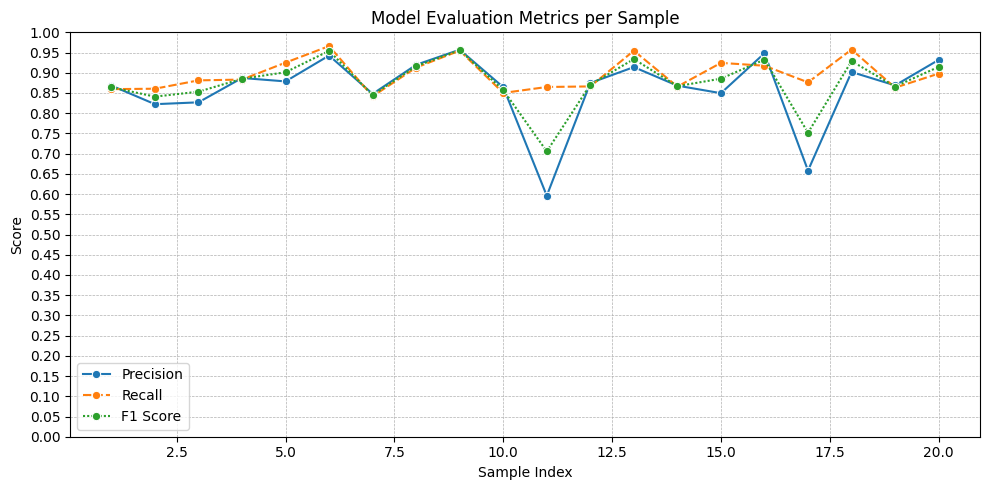

In [ ]:
import numpy as np

plt.figure(figsize=(10, 5))
sns.lineplot(data=df.set_index("Sample")[["Precision", "Recall", "F1 Score"]], marker="o")

plt.title("Model Evaluation Metrics per Sample")
plt.xlabel("Sample Index")
plt.ylabel("Score")
plt.ylim(0, 1.0)  # Y-axis starts from 0
plt.yticks(np.arange(0, 1.05, 0.05))  # More granularity in ticks: 0.00, 0.05, ..., 1.00
plt.grid(True, linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import numpy as np

# Metric functions
smoothie = SmoothingFunction().method4

def exact_match(pred, ref):
    return int(pred.strip().lower() == ref.strip().lower())

def token_f1(pred, ref):
    pred_tokens = pred.split()
    ref_tokens = ref.split()
    common = set(pred_tokens) & set(ref_tokens)
    if not common:
        return 0
    precision = len(common) / len(pred_tokens) if pred_tokens else 0
    recall = len(common) / len(ref_tokens) if ref_tokens else 0
    return 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

# Compute scores
df = pd.DataFrame({
    "Sample": list(range(1, len(predictions)+1)),
    "Prediction": predictions,
    "Reference": references,
    "BLEU": [sentence_bleu([r.split()], p.split(), smoothing_function=smoothie) for p, r in zip(predictions, references)],
    "Exact Match": [exact_match(p, r) for p, r in zip(predictions, references)],
    "Token F1": [token_f1(p, r) for p, r in zip(predictions, references)],
    "Answer Length": [len(p.split()) for p in predictions]
})


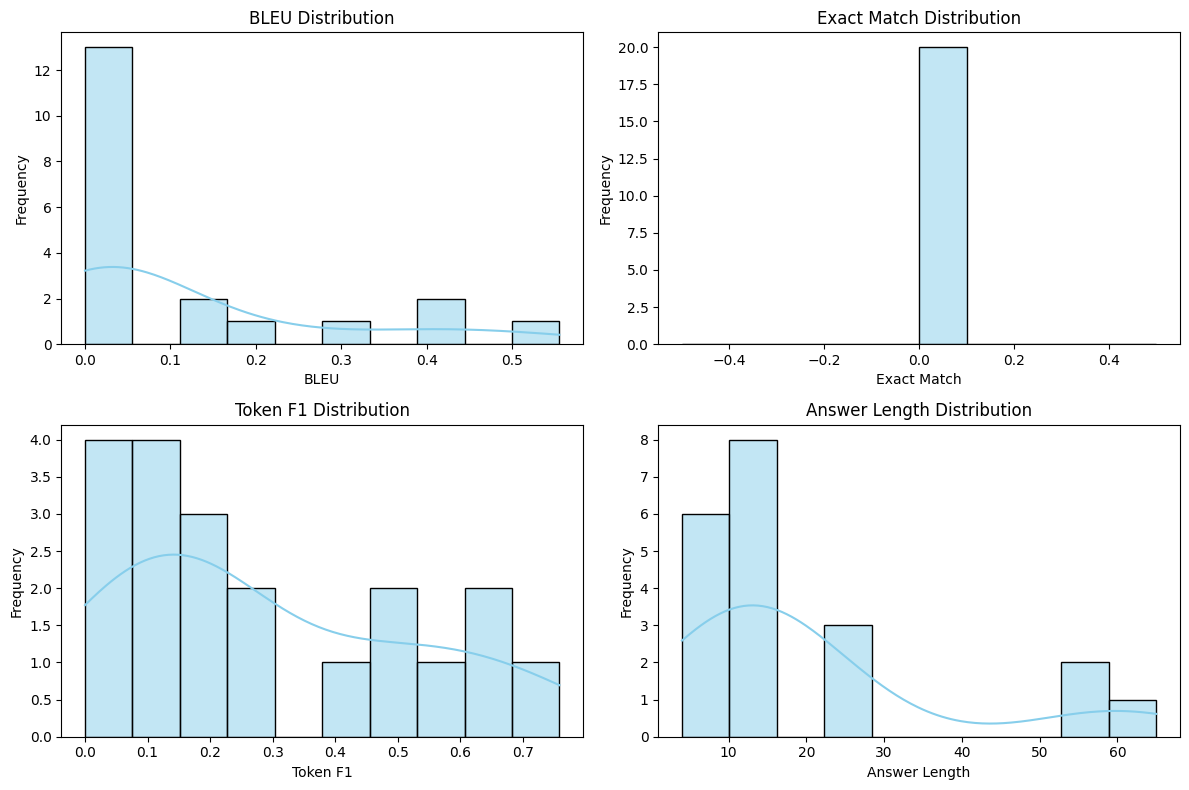

In [ ]:
metrics = ["BLEU", "Exact Match", "Token F1", "Answer Length"]

fig, axs = plt.subplots(2, 2, figsize=(12, 8))
axs = axs.flatten()

for i, metric in enumerate(metrics):
    sns.histplot(df[metric], bins=10, kde=True, ax=axs[i], color="skyblue")
    axs[i].set_title(f"{metric} Distribution")
    axs[i].set_xlabel(metric)
    axs[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


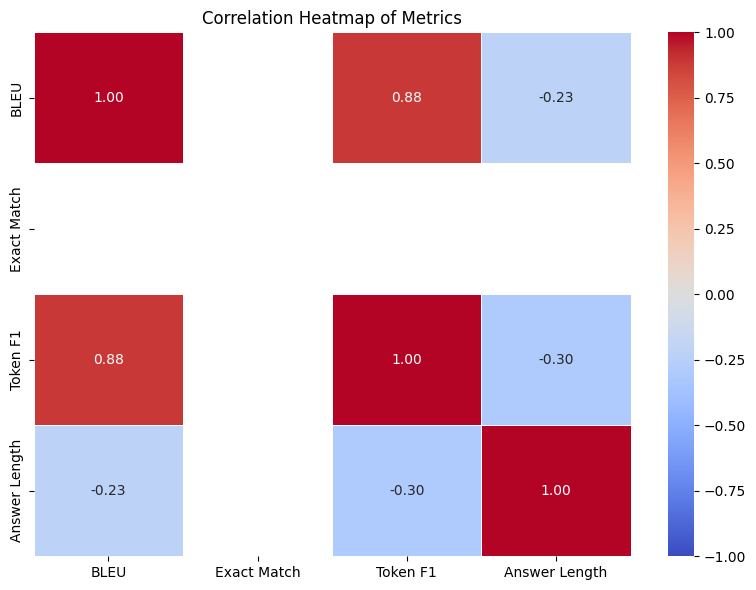

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[metrics].corr(), annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Metrics")
plt.tight_layout()
plt.show()


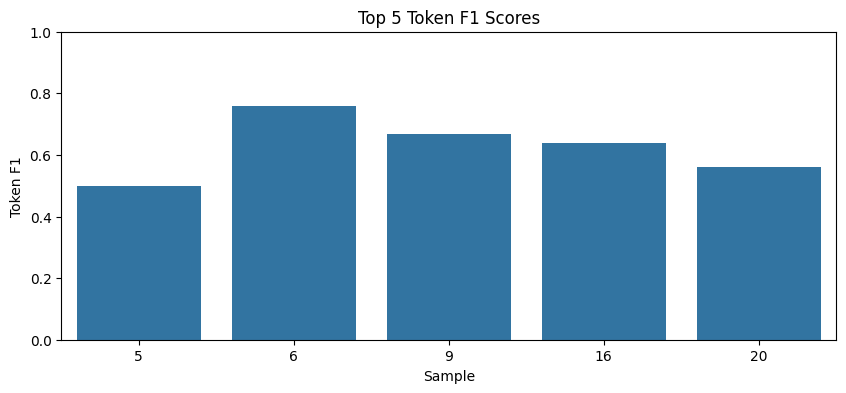

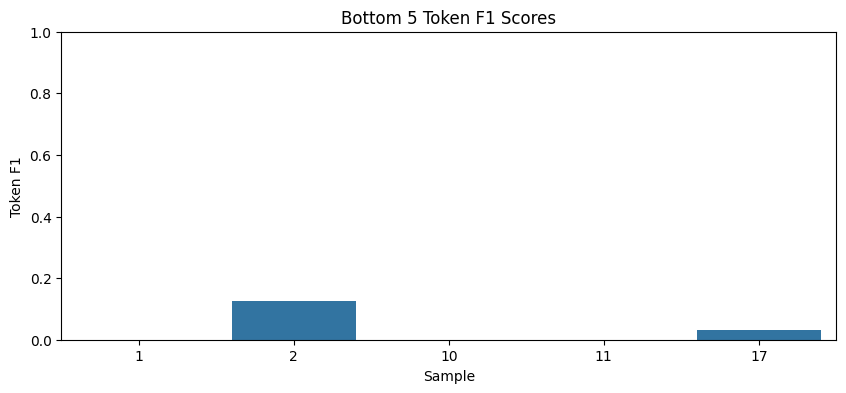

In [ ]:
df_sorted = df.sort_values("Token F1", ascending=False)

plt.figure(figsize=(10, 4))
sns.barplot(x="Sample", y="Token F1", data=df_sorted.head(5))
plt.title("Top 5 Token F1 Scores")
plt.ylim(0, 1)
plt.show()

plt.figure(figsize=(10, 4))
sns.barplot(x="Sample", y="Token F1", data=df_sorted.tail(5))
plt.title("Bottom 5 Token F1 Scores")
plt.ylim(0, 1)
plt.show()
